Aluno: Lucas Barbosa dos Santos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

drive.mount("/content/drive")
file_path = "/content/drive/My Drive/Colab Notebooks"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_train = pd.read_csv(file_path + "/DailyDelhiClimateTrain.csv")
df_train.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [ ]:
df_test = pd.read_csv(file_path + "/DailyDelhiClimateTest.csv")
df_test.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [ ]:
df = pd.concat([df_train, df_test], ignore_index=True)
df

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
1571,2017-04-20,34.500000,27.500000,5.562500,998.625000
1572,2017-04-21,34.250000,39.375000,6.962500,999.875000
1573,2017-04-22,32.900000,40.900000,8.890000,1001.600000
1574,2017-04-23,32.875000,27.500000,9.962500,1002.125000


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1576 non-null   datetime64[ns]
 1   meantemp      1576 non-null   float64       
 2   humidity      1576 non-null   float64       
 3   wind_speed    1576 non-null   float64       
 4   meanpressure  1576 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 61.7 KB


In [ ]:
df.describe()

,date,meantemp,humidity,wind_speed,meanpressure
count,1576,1576.000000,1576.000000,1576.000000,1576.000000
mean,2015-02-27 10:15:50.253807104,25.221918,60.445229,6.899262,1010.593178
min,2013-01-01 00:00:00,6.000000,13.428571,0.000000,-3.041667
25%,2014-01-29 18:00:00,18.500000,49.750000,3.700000,1001.875000
50%,2015-02-27 12:00:00,27.166667,62.440476,6.363571,1009.055556
75%,2016-03-27 06:00:00,31.142857,72.125000,9.262500,1015.200000
max,2017-04-24 00:00:00,38.714286,100.000000,42.220000,7679.333333
std,NaN,7.345014,16.979994,4.510725,175.242704


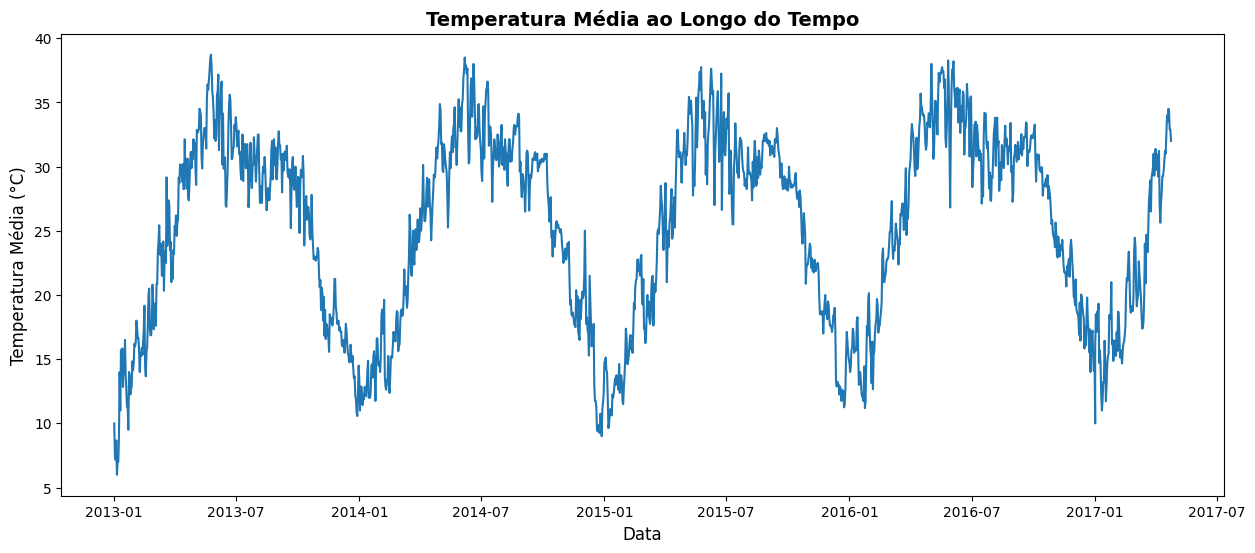

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df['date'], df['meantemp'])
ax.set_title("Temperatura Média ao Longo do Tempo", fontsize=14, fontweight="bold")
ax.set_xlabel("Data", fontsize=12)
ax.set_ylabel("Temperatura Média (°C)", fontsize=12)
plt.show()

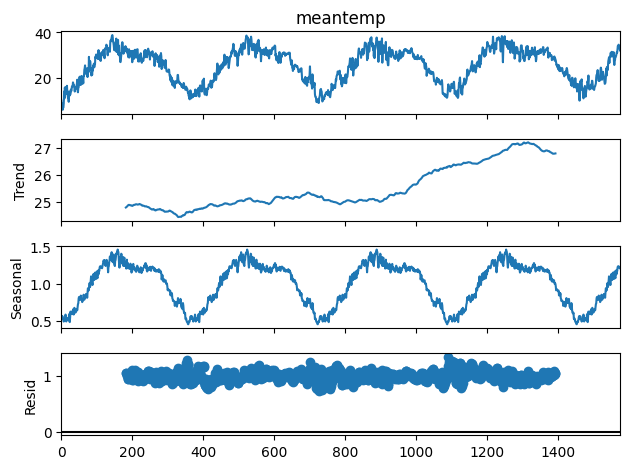

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['meantemp'], model='multiplicative', period=365)
result.plot()
plt.show()

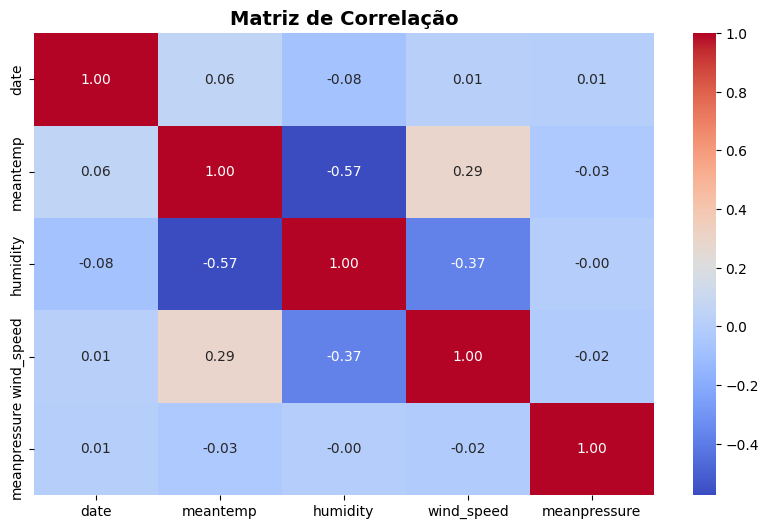

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação", fontsize=14, fontweight="bold")
plt.show()

In [ ]:
features = ['humidity', 'wind_speed', 'meanpressure']
target = 'meantemp'
seq_len = 7 # 1 semana para prever 1 dia

X, y = [], []
for i in range(len(df) - seq_len):
    X.append(df[features].iloc[i:i+seq_len].values)
    y.append(df[target].iloc[i+seq_len])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

In [ ]:
X.shape

(1569, 7, 3)

In [ ]:
y.shape

(1569,)

In [ ]:
X = np.transpose(X, (0, 2, 1))
X.shape # (n_samples, n_features, seq_len)

(1569, 3, 7)

In [ ]:
!pip install tsai

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.1/324.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.0/278.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 78.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cusparselt-cu12
    Found existing installation: nvidia-cusparselt-cu12 0.7.1
    Uninstalling nvidia-cusp

In [ ]:
from tsai.all import *

In [ ]:
splits = TimeSplitter(valid_size=0.2)(range(len(X)))

X      - shape: [1569 samples x 3 features x 7 timesteps]  type: ndarray  dtype:float32  isnan: 0
y      - shape: (1569,)  type: ndarray  dtype:float32  isnan: 0
splits - n_splits: 2 shape: [1255, 314]  overlap: False


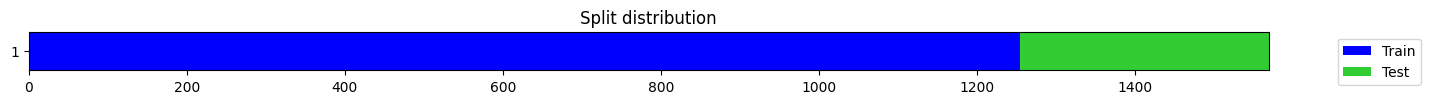

In [ ]:
check_data(X, y, splits=splits)

In [ ]:
batch_tfms = TSStandardize()
dls = get_ts_dls(X, y, splits=splits, bs=64, batch_tfms=batch_tfms)

In [ ]:
dls.show_batch()

In [ ]:
learn = ts_learner(dls, LSTM, metrics=[mae, rmse], cbs=ShowGraph())

In [ ]:
learn.lr_find()

In [ ]:
learn.fit_one_cycle(30,1e-2)

In [ ]:
learn.show_results()